# U-DIADS-TL Dataset to YOLO Format Converter

This notebook converts the U-DIADS-TL dataset from binary ground truth images to YOLO format.
Each text line is represented as a connected component in the binary images, and we extract
bounding boxes from these connected components.

**Dataset subsets:** Latin14396, Latin2, Syr341

In [1]:
# Imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import yaml
import shutil
import os
from pathlib import Path


In [2]:
def extract_bboxes_from_connected_components(binary_img):
    """
    Extract bounding boxes from connected components in a binary image.
    Each connected component represents a text line.
    
    Args:
        binary_img: Binary image (numpy array) where text lines are white connected components
    
    Returns:
        List of bounding boxes as (x_min, y_min, x_max, y_max) tuples
    """
    # Ensure grayscale
    if len(binary_img.shape) > 2:
        binary_img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
    
    # Ensure binary (threshold if needed)
    _, binary = cv2.threshold(binary_img, 127, 255, cv2.THRESH_BINARY)
    
    # Find connected components
    num_labels, labels = cv2.connectedComponents(binary)
    
    bboxes = []
    for label in range(1, num_labels):  # Skip background (label 0)
        # Get coordinates of this component
        component_mask = (labels == label)
        coords = np.where(component_mask)
        
        if len(coords[0]) == 0 or len(coords[1]) == 0:
            continue
        
        # Calculate bounding box
        y_min, y_max = coords[0].min(), coords[0].max()
        x_min, x_max = coords[1].min(), coords[1].max()
        
        # Only keep reasonably sized components (filter noise)
        width = x_max - x_min
        height = y_max - y_min
        if width > 5 and height > 5:  # Minimum size threshold
            bboxes.append((x_min, y_min, x_max, y_max))
    
    return bboxes


In [3]:
def bbox_to_yolo_format(bbox, img_width, img_height):
    """
    Convert bounding box to YOLO format (center_x, center_y, width, height) normalized
    """
    x_min, y_min, x_max, y_max = bbox
    
    # Calculate center coordinates
    center_x = (x_min + x_max) / 2.0
    center_y = (y_min + y_max) / 2.0
    
    # Calculate width and height
    width = x_max - x_min
    height = y_max - y_min
    
    # Normalize by image dimensions
    center_x /= img_width
    center_y /= img_height
    width /= img_width
    height /= img_height
    
    return center_x, center_y, width, height


In [4]:
def convert_binary_to_yolo_labels(binary_img_path, output_label_path):
    """
    Convert binary ground truth image to YOLO format labels
    """
    # Read binary image
    binary_img = cv2.imread(binary_img_path, cv2.IMREAD_GRAYSCALE)
    if binary_img is None:
        print(f"Warning: Could not read binary image {binary_img_path}")
        return False
    
    img_height, img_width = binary_img.shape
    
    # Extract bounding boxes from connected components
    bboxes = extract_bboxes_from_connected_components(binary_img)
    
    # Convert to YOLO format
    yolo_labels = []
    for bbox in bboxes:
        yolo_bbox = bbox_to_yolo_format(bbox, img_width, img_height)
        # YOLO format: class_id center_x center_y width height
        yolo_labels.append(f"0 {yolo_bbox[0]:.6f} {yolo_bbox[1]:.6f} {yolo_bbox[2]:.6f} {yolo_bbox[3]:.6f}")
    
    # Write YOLO labels to file
    with open(output_label_path, 'w') as f:
        f.write('\n'.join(yolo_labels))
    
    return True


In [5]:
def visualize_text_lines(img_path, yolo_labels_path=None):
    """
    Visualize text line bounding boxes on image
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image {img_path}")
        return
    
    img_display = img.copy()
    img_height, img_width = img.shape[:2]
    
    bboxes = []
    if yolo_labels_path and os.path.exists(yolo_labels_path):
        with open(yolo_labels_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, width, height = map(float, parts)
                    # Convert from normalized YOLO format to pixel coordinates
                    center_x *= img_width
                    center_y *= img_height
                    width *= img_width
                    height *= img_height
                    
                    x_min = center_x - width / 2
                    y_min = center_y - height / 2
                    x_max = center_x + width / 2
                    y_max = center_y + height / 2
                    
                    bboxes.append((x_min, y_min, x_max, y_max))
    
    # Draw bounding boxes
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_display, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Text Lines Detected - {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()
    
    print(f"Detected {len(bboxes)} text lines")


In [6]:
def process_dataset_split(img_dir, binary_dir, out_img_dir, out_label_dir):
    """
    Process a dataset split (train/val/test) for U-DIADS-TL
    """
    # Create output directories
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)
    
    # Get list of image files
    img_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        img_files.extend(Path(img_dir).glob(ext))
    
    processed_count = 0
    total_text_lines = 0
    
    for img_file in img_files:
        # Find corresponding binary ground truth file
        img_name = img_file.stem
        binary_file = Path(binary_dir) / f"{img_name}.png"
        
        if not binary_file.exists():
            print(f"Warning: Binary GT not found for {img_file.name}")
            continue
        
        # Define output paths
        output_img_path = Path(out_img_dir) / img_file.name
        output_label_path = Path(out_label_dir) / f"{img_name}.txt"
        
        # Copy image to output directory
        shutil.copy2(img_file, output_img_path)
        
        # Convert binary image to YOLO labels
        success = convert_binary_to_yolo_labels(str(binary_file), str(output_label_path))
        if success:
            # Count text lines
            with open(output_label_path, 'r') as f:
                line_count = len([line for line in f if line.strip()])
            total_text_lines += line_count
            print(f"[OK] {img_file.name} → {line_count} text lines")
            processed_count += 1
        else:
            print(f"[FAIL] {img_file.name} → Failed to process")
    
    print(f"\nProcessed {processed_count} images with {total_text_lines} total text lines in {Path(img_dir).name}")
    return processed_count, total_text_lines


In [7]:
def create_yolo_config(dataset_path, output_yaml_path="dataset.yaml"):
    """
    Create YOLO dataset configuration file
    """
    dataset_path = Path(dataset_path)
    
    # Define class names
    names = {
        0: "textline"
    }
    
    # Create dataset configuration
    config = {
        "path": str(dataset_path),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": names
    }
    
    # Write YAML file
    with open(output_yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    
    print(f"✓ Created YOLO config: {output_yaml_path}")


In [8]:
def show_random_sample(dataset_path):
    """
    Display a random image with detected text lines
    """
    dataset_path = Path(dataset_path)
    
    # Get all image files
    image_files = []
    for split in ["train", "val", "test"]:
        split_dir = dataset_path / "images" / split
        if split_dir.exists():
            image_files.extend(list(split_dir.glob("*")))
    
    if not image_files:
        print("No images found in dataset")
        return
    
    # Select random image
    random_img = random.choice(image_files)
    
    # Find corresponding label file
    label_file = dataset_path / "labels" / random_img.parent.name / f"{random_img.stem}.txt"
    
    # Visualize
    visualize_text_lines(str(random_img), str(label_file))


In [15]:
# Configuration - U-DIADS-TL Dataset Subsets
# Available subsets: Latin14396, Latin2, Syr341

DATASET_CONFIG = {
    "Latin14396": {
        "img_base": "../00_data/U-DIADS-TL/Latin14396/img-Latin14396",
        "gt_base": "../00_data/U-DIADS-TL/Latin14396/text-line-gt-Latin14396",
        "output_dir": "../00_data/U-DIADS-TL/yolo_dataset_latin14396"
    },
    "Latin2": {
        "img_base": "../00_data/U-DIADS-TL/Latin2/img-Latin2",
        "gt_base": "../00_data/U-DIADS-TL/Latin2/text-line-gt-Latin2",
        "output_dir": "../00_data/U-DIADS-TL/yolo_dataset_latin2"
    },
    "Syr341": {
        "img_base": "../00_data/U-DIADS-TL/Syr341/img-Syr341",
        "gt_base": "../00_data/U-DIADS-TL/Syr341/text-line-gt-Syr341",
        "output_dir": "../00_data/U-DIADS-TL/yolo_dataset_syr341"
    }
}

# SELECT SUBSET TO PROCESS
SELECTED_SUBSET = "Syr341"  # Change to "Latin2" or "Syr341"

config = DATASET_CONFIG[SELECTED_SUBSET]
print(f"Selected subset: {SELECTED_SUBSET}")
print(f"Output directory: {config['output_dir']}")


Selected subset: Syr341
Output directory: ../00_data/U-DIADS-TL/yolo_dataset_syr341


In [16]:
# Process the selected U-DIADS-TL subset
print(f"🚀 Processing U-DIADS-TL {SELECTED_SUBSET}...\n")

total_images = 0
total_text_lines = 0

# Process training set
print("📁 Processing training set...")
img_count, line_count = process_dataset_split(
    img_dir=f"{config['img_base']}/training",
    binary_dir=f"{config['gt_base']}/training",
    out_img_dir=f"{config['output_dir']}/images/train",
    out_label_dir=f"{config['output_dir']}/labels/train"
)
total_images += img_count
total_text_lines += line_count

# Process validation set
print("📁 Processing validation set...")
img_count, line_count = process_dataset_split(
    img_dir=f"{config['img_base']}/validation",
    binary_dir=f"{config['gt_base']}/validation",
    out_img_dir=f"{config['output_dir']}/images/val",
    out_label_dir=f"{config['output_dir']}/labels/val"
)
total_images += img_count
total_text_lines += line_count

# Process test set
print("📁 Processing test set...")
img_count, line_count = process_dataset_split(
    img_dir=f"{config['img_base']}/test",
    binary_dir=f"{config['gt_base']}/test",
    out_img_dir=f"{config['output_dir']}/images/test",
    out_label_dir=f"{config['output_dir']}/labels/test"
)
total_images += img_count
total_text_lines += line_count

# Create YOLO configuration
create_yolo_config(config["output_dir"], f"{config['output_dir']}/dataset.yaml")

print(f"\n✅ Dataset processing complete!")
print(f"📊 Total images processed: {total_images}")
print(f"📝 Total text lines detected: {total_text_lines}")
print(f"📂 YOLO dataset created at: {config['output_dir']}")


🚀 Processing U-DIADS-TL Syr341...

📁 Processing training set...
[OK] 161.jpg → 180 text lines
[OK] 082.jpg → 188 text lines
[OK] 240.jpg → 95 text lines

Processed 3 images with 463 total text lines in training
📁 Processing validation set...
[OK] 198.jpg → 182 text lines
[OK] 039.jpg → 175 text lines
[OK] 166.jpg → 181 text lines
[OK] 133.jpg → 181 text lines
[OK] 025.jpg → 182 text lines
[OK] 428.jpg → 149 text lines
[OK] 328.jpg → 146 text lines
[OK] 278.jpg → 183 text lines
[OK] 143.jpg → 184 text lines
[OK] 338.jpg → 184 text lines

Processed 10 images with 1747 total text lines in validation
📁 Processing test set...
[OK] 286.jpg → 186 text lines
[OK] 190.jpg → 169 text lines
[OK] 053.jpg → 149 text lines
[OK] 071.jpg → 186 text lines
[OK] 031.jpg → 187 text lines
[OK] 073.jpg → 190 text lines
[OK] 150.jpg → 186 text lines
[OK] 252.jpg → 177 text lines
[OK] 313.jpg → 183 text lines
[OK] 362.jpg → 152 text lines
[OK] 224.jpg → 185 text lines
[OK] 167.jpg → 186 text lines
[OK] 290.jp

🎨 Showing random sample with detected text lines...


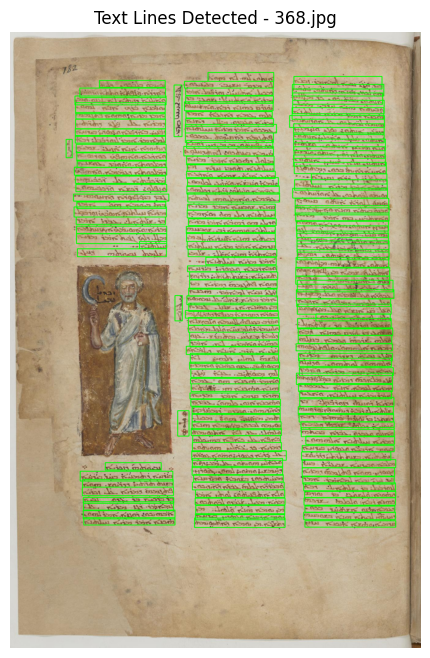

Detected 152 text lines


In [17]:
# Visualize a random sample
print("🎨 Showing random sample with detected text lines...")
show_random_sample(config["output_dir"])
